In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
plt.rcParams['font.family'] = 'Arial'

In [2]:
df = pd.read_csv('data/robustness_to_error_1e4.csv')
df

,n_mut,mut_type,seed,genotypes_nnz,brick_graph_nnz,linarg_nnz,linarg_ratio,brick_graph_ratio
0,0,back,1,19622209,2230224,293560,66.842243,8.798313
1,0,back,2,20143978,2269334,295399,68.192438,8.876603
2,0,back,3,20146575,2313257,296097,68.040456,8.709181
3,0,back,4,21509435,2349112,296470,72.551810,9.156411
4,0,back,5,20986356,2350379,294439,71.275735,8.928924
...,...,...,...,...,...,...,...,...
3978,10000,position,96,19993768,13971476,2073890,9.640708,1.431042
3979,10000,position,97,20433642,14171142,2127172,9.606013,1.441919
3980,10000,position,98,19623380,13909890,2164274,9.066957,1.410750
3981,10000,position,99,20689851,14202907,2011499,10.285787,1.456734


In [3]:
mut_types = ['back', 'recurrent', 'error', 'position']

mut_type_mapping = {
    'back': 'back mutation',
    'recurrent': 'recurrent mutation',
    'error': 'genotying error',
    'position': 'out-of-order error'
}

n_mutation_list = [0, 50, 100, 500, 1000, 5000, 10000, 20000, 30000, 40000, 50000]

colors = [
    '#59b330ff', # green
    '#E9B824', # yellow
    '#F77F00', # orange
    '#56C1FF', # blue
]

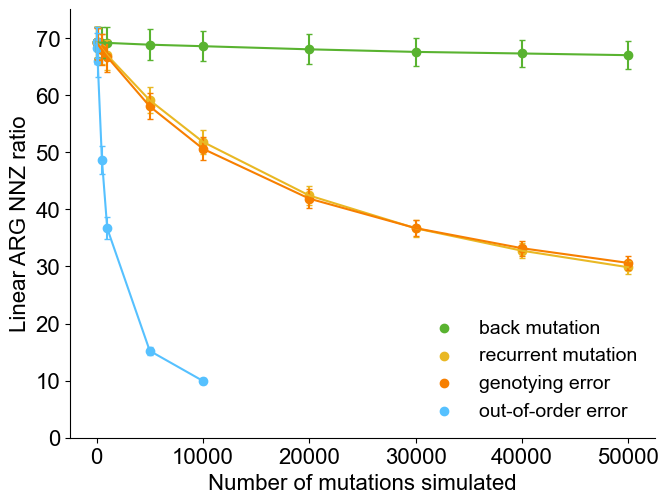

In [4]:
for i in range(len(mut_types)):
    
    df_sub = df[df.mut_type==mut_types[i]]
    means = [np.mean(df_sub[df_sub.n_mut==n_mut].linarg_ratio) for n_mut in n_mutation_list]
    stds = np.array([np.std(df_sub[df_sub.n_mut==n_mut].linarg_ratio) for n_mut in n_mutation_list])
    
    plt.scatter(n_mutation_list, means, label=mut_type_mapping[mut_types[i]], color=colors[i])
    plt.errorbar(n_mutation_list, means, yerr=stds, capsize=2, color=colors[i])
    
plt.legend(frameon=False, fontsize=14)
plt.tight_layout()
plt.xlabel('Number of mutations simulated', fontsize=16)
plt.ylabel('Linear ARG NNZ ratio', fontsize=16)
plt.tick_params(axis='both', labelsize=16)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.ylim(0, 75)
plt.show()

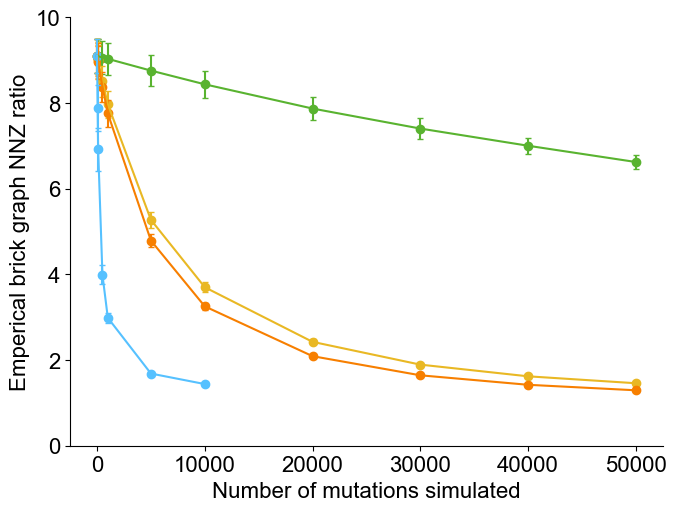

In [5]:
for i in range(len(mut_types)):
    
    df_sub = df[df.mut_type==mut_types[i]]
    means = [np.mean(df_sub[df_sub.n_mut==n_mut].brick_graph_ratio) for n_mut in n_mutation_list]
    stds = np.array([np.std(df_sub[df_sub.n_mut==n_mut].brick_graph_ratio) for n_mut in n_mutation_list])
    
    plt.scatter(n_mutation_list, means, label=mut_type_mapping[mut_types[i]], color=colors[i])
    plt.errorbar(n_mutation_list, means, yerr=stds, capsize=2, color=colors[i])
    
plt.tight_layout()
plt.xlabel('Number of mutations simulated', fontsize=16)
plt.ylabel('Emperical brick graph NNZ ratio', fontsize=16)
plt.tick_params(axis='both', labelsize=16)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.ylim(0, 10)
plt.show()